<a href="https://colab.research.google.com/github/trialdyk/PCVK-Ganjil-2026/blob/main/Week02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 02 - Pengantar Citra Digital dan Visi Komputer

## Persiapan dan Load Citra

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from google.colab.patches import cv2_imshow
from google.colab import files

image_path = 'foto_aktivitas.jpg'

try:
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError
except FileNotFoundError:
    uploaded = files.upload()
    image_path = next(iter(uploaded))
    img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print('Nama file:', image_path)
print('Shape:', img.shape)
print('Dtype:', img.dtype)

## Praktikum 1 - Menampilkan Citra

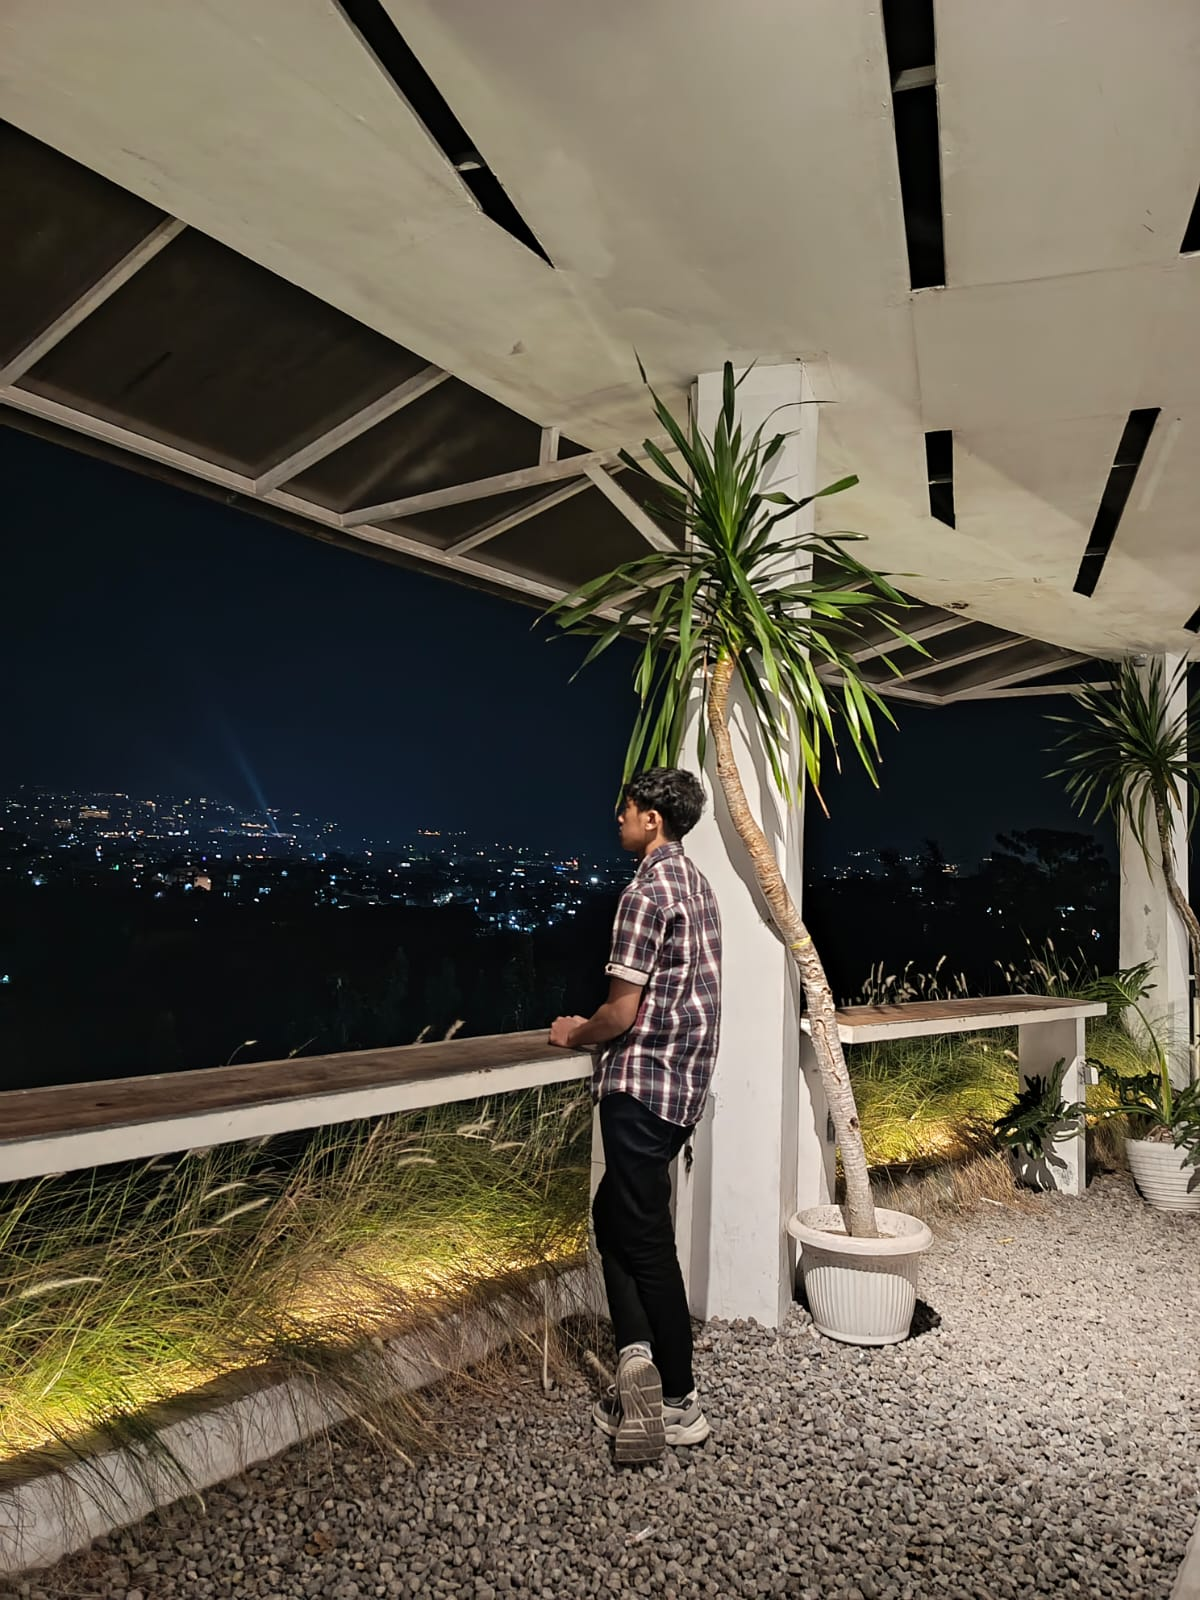

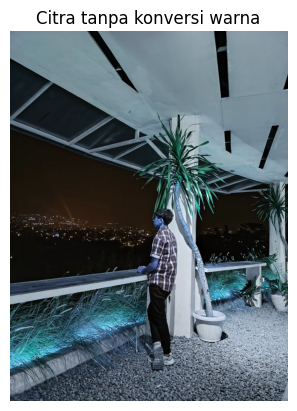

In [23]:
cv2_imshow(img)

plt.imshow(img)
plt.title('Citra tanpa konversi warna')
plt.axis('off')
plt.show()

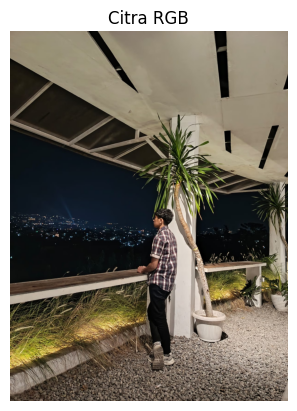

In [24]:
plt.imshow(img_rgb)
plt.title('Citra RGB')
plt.axis('off')
plt.show()

## Praktikum 2 - Grayscale, Resize, dan Flipping

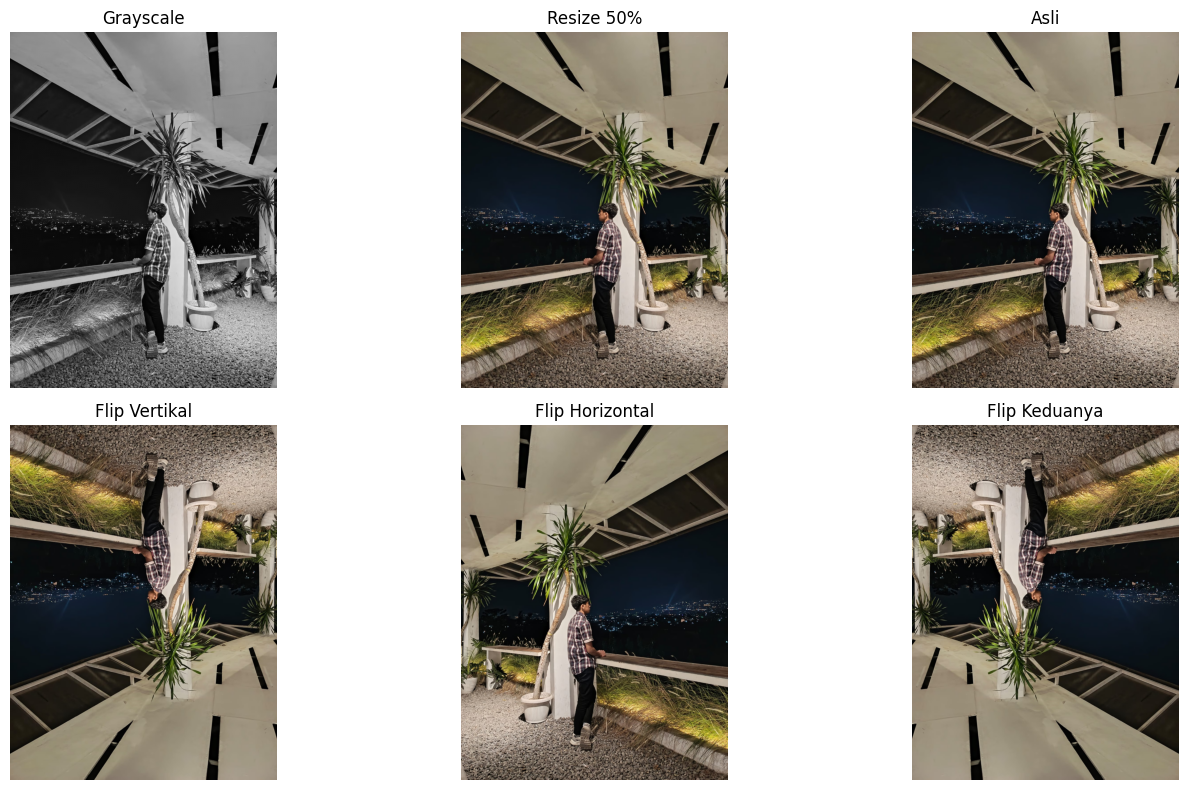

In [25]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
resized = cv2.resize(img_rgb, (img_rgb.shape[1] // 2, img_rgb.shape[0] // 2))
vertical = cv2.flip(img_rgb, 0)
horizontal = cv2.flip(img_rgb, 1)
both = cv2.flip(img_rgb, -1)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax[0, 0].imshow(gray, cmap='gray'); ax[0, 0].set_title('Grayscale')
ax[0, 1].imshow(resized); ax[0, 1].set_title('Resize 50%')
ax[0, 2].imshow(img_rgb); ax[0, 2].set_title('Asli')
ax[1, 0].imshow(vertical); ax[1, 0].set_title('Flip Vertikal')
ax[1, 1].imshow(horizontal); ax[1, 1].set_title('Flip Horizontal')
ax[1, 2].imshow(both); ax[1, 2].set_title('Flip Keduanya')
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()

## Praktikum 3 - Bentuk Geometri dan Teks

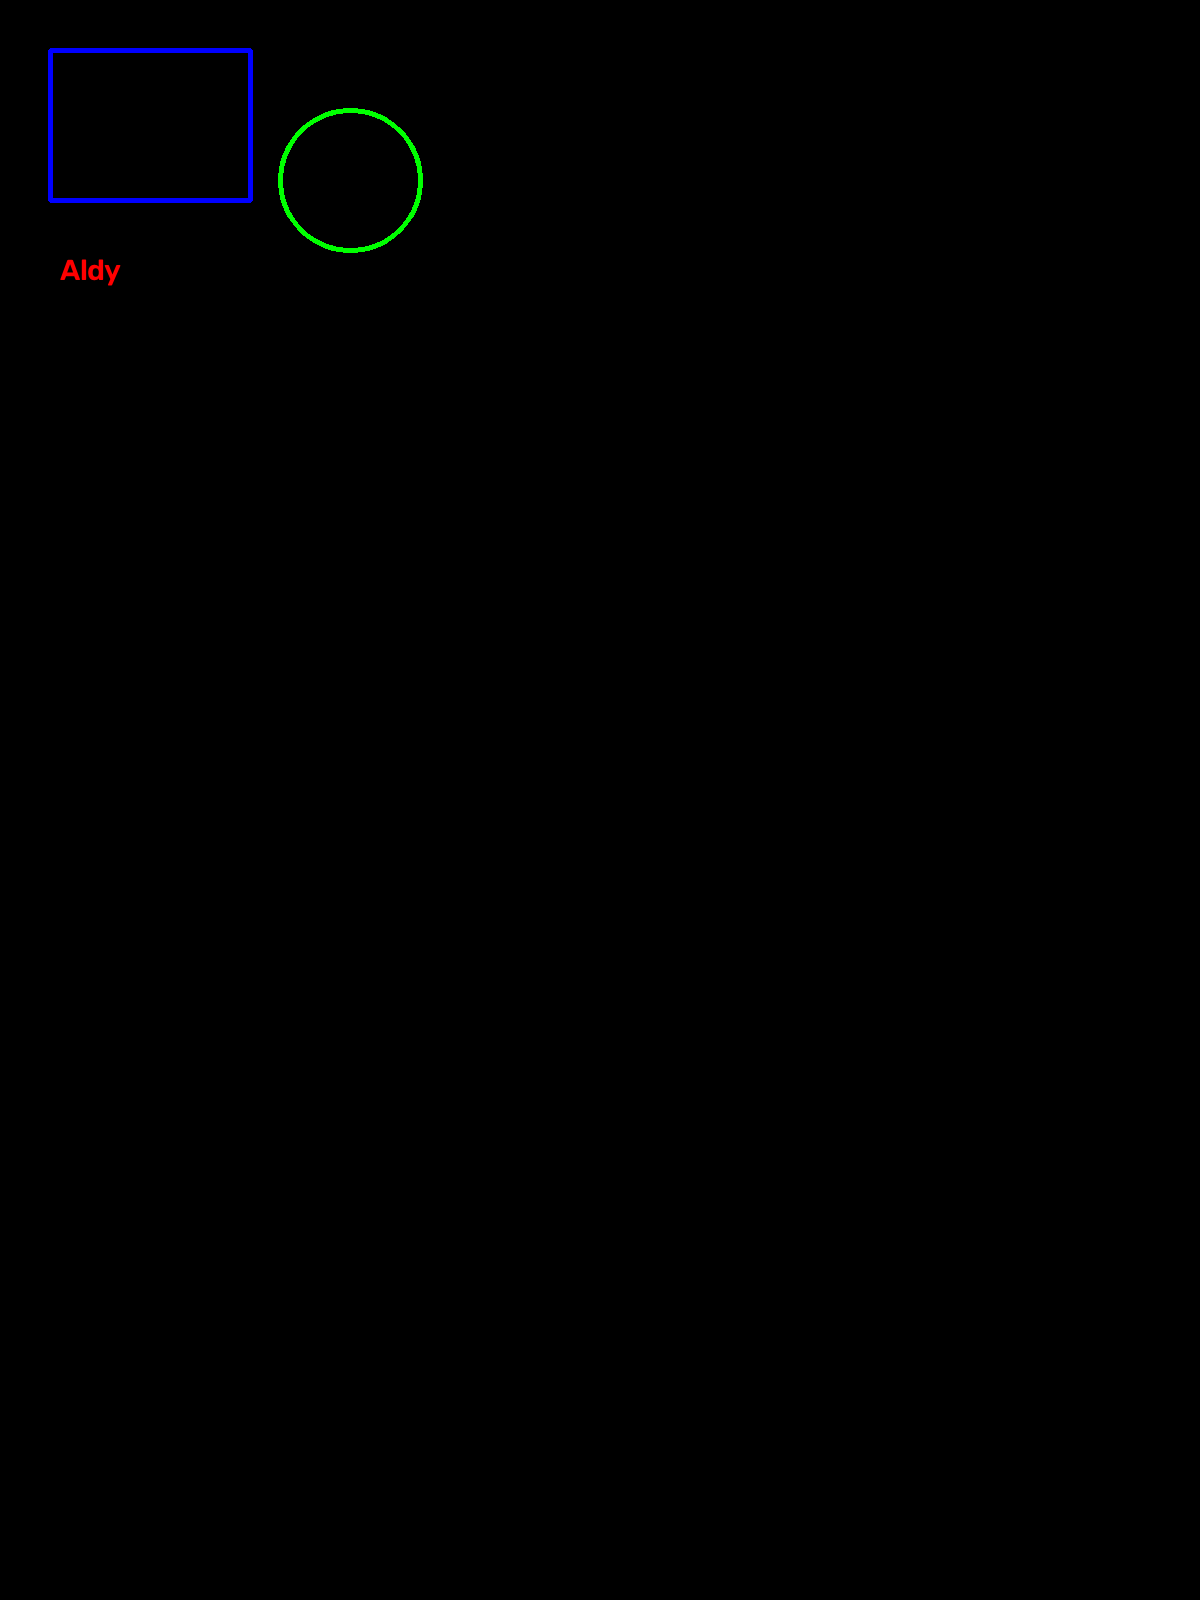

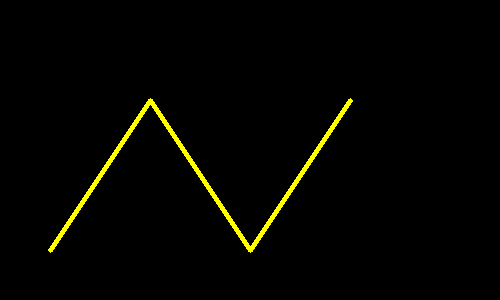

In [26]:
canvas16 = np.zeros_like(img, dtype=np.int16)

cv2.rectangle(canvas16, (50, 50), (250, 200), (255, 0, 0), 3)
cv2.circle(canvas16, (350, 180), 70, (0, 255, 0), 3)

canvas16_display = np.clip(canvas16, 0, 255).astype(np.uint8)
cv2.putText(
    canvas16_display,
    'Aldy',
    (60, 280),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 0, 255),
    2
)

cv2_imshow(canvas16_display)

canvas32 = np.zeros((300, 500, 3), dtype=np.int32)
points = np.array(
    [[50, 250], [150, 100], [250, 250], [350, 100]],
    np.int32
).reshape((-1, 1, 2))

canvas32_display = np.clip(canvas32, 0, 255).astype(np.uint8)
cv2.polylines(canvas32_display, [points], False, (0, 255, 255), 3)
cv2_imshow(canvas32_display)


## Pertanyaan Praktikum 1 - BGR dan RGB

In [27]:
pixel_bgr = img[0, 0]
pixel_rgb = img_rgb[0, 0]
print('Piksel dengan cv2.imread (BGR):', pixel_bgr)
print('Piksel setelah konversi RGB:', pixel_rgb)
print('cv2_imshow menampilkan BGR dengan benar karena menyesuaikan format OpenCV.')
print('plt.imshow menganggap input sebagai RGB, sehingga img BGR tampak tertukar.')

Piksel dengan cv2.imread (BGR): [108 128 145]
Piksel setelah konversi RGB: [145 128 108]
cv2_imshow menampilkan BGR dengan benar karena menyesuaikan format OpenCV.
plt.imshow menganggap input sebagai RGB, sehingga img BGR tampak tertukar.


## Pertanyaan Praktikum 2 - int16 dan int32

In [28]:
black16 = np.zeros(img.shape, dtype=np.int16)
black32 = np.zeros(img.shape, dtype=np.int32)
for name, canvas in [('int16', black16), ('int32', black32)]:
    print(name, '| dtype:', canvas.dtype, '| min:', canvas.min(), '| max:', canvas.max(), '| nbytes:', canvas.nbytes)
print('Tampilan sama karena keduanya berisi nilai nol.')
print('Memori int32 lebih besar karena setiap elemen memakai 4 byte, sedangkan int16 memakai 2 byte.')

int16 | dtype: int16 | min: 0 | max: 0 | nbytes: 11520000
int32 | dtype: int32 | min: 0 | max: 0 | nbytes: 23040000
Tampilan sama karena keduanya berisi nilai nol.
Memori int32 lebih besar karena setiap elemen memakai 4 byte, sedangkan int16 memakai 2 byte.


## Pertanyaan Praktikum 3 - cv2_imshow

`cv2_imshow()` berasal dari `google.colab.patches` dan disediakan untuk menampilkan citra pada output notebook Colab. `cv2.imshow()` bawaan OpenCV membutuhkan jendela GUI lokal, sedangkan Colab berjalan pada lingkungan cloud tanpa desktop GUI.

## Pertanyaan Praktikum 4 - skimage dan OpenCV

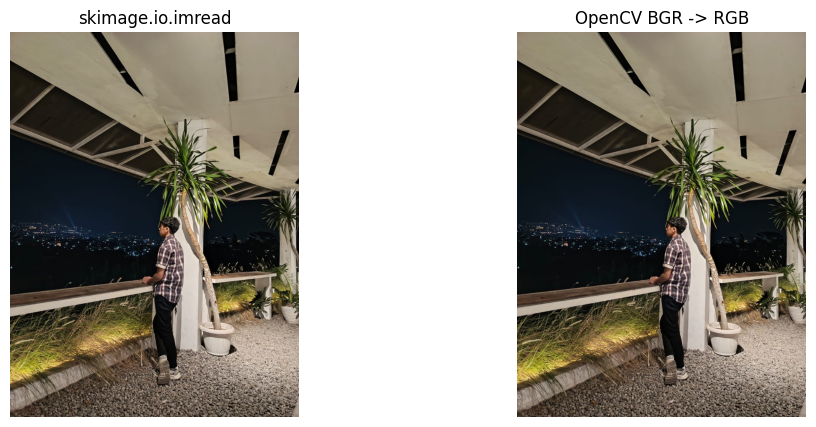

Piksel skimage RGB: [145 128 108]
Piksel OpenCV setelah RGB: [145 128 108]
Keduanya menampilkan warna sebenarnya karena keduanya menggunakan urutan RGB.


In [29]:
img_skimage = io.imread(image_path)
img_cv_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img_skimage); ax[0].set_title('skimage.io.imread')
ax[1].imshow(img_cv_rgb); ax[1].set_title('OpenCV BGR -> RGB')
for a in ax: a.axis('off')
plt.show()

print('Piksel skimage RGB:', img_skimage[0, 0])
print('Piksel OpenCV setelah RGB:', img_cv_rgb[0, 0])
print('Keduanya menampilkan warna sebenarnya karena keduanya menggunakan urutan RGB.')

## Pertanyaan Praktikum 5 - Ukuran Citra dan Ukuran Tampilan

Shape sebelum figsize: (1600, 1200, 3)


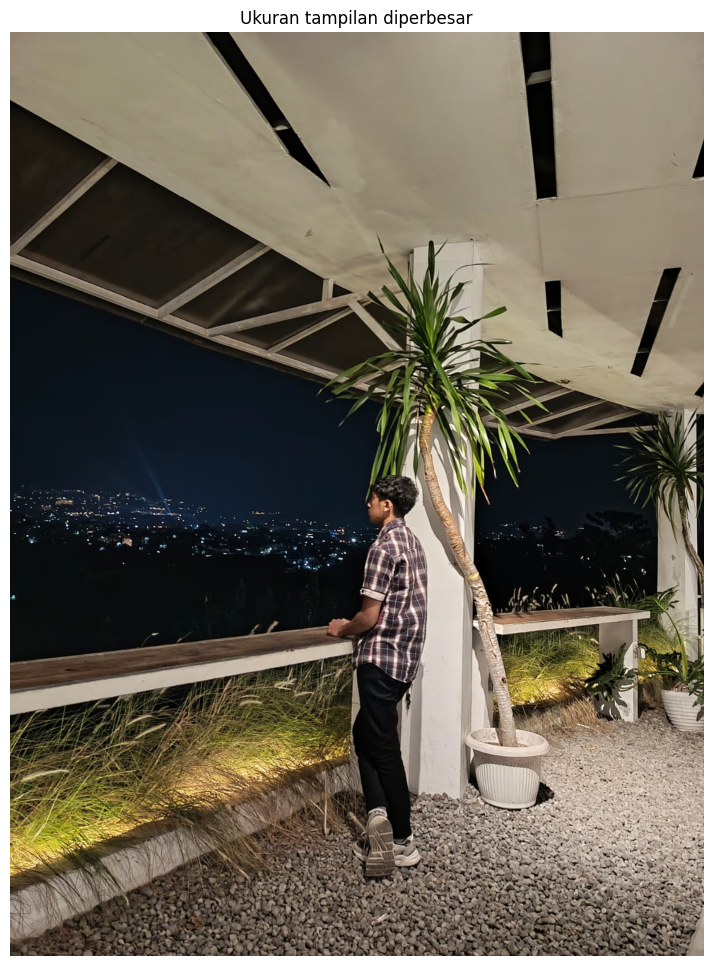

Shape setelah figsize: (1600, 1200, 3)
figsize hanya mengubah ukuran tampilan, bukan jumlah piksel citra.


In [30]:
print('Shape sebelum figsize:', img_rgb.shape)
plt.figure(figsize=(18, 12))
plt.imshow(img_rgb)
plt.title('Ukuran tampilan diperbesar')
plt.axis('off')
plt.show()
print('Shape setelah figsize:', img_rgb.shape)
print('figsize hanya mengubah ukuran tampilan, bukan jumlah piksel citra.')

## Tugas Penerapan 1 - Kombinasi Kanal

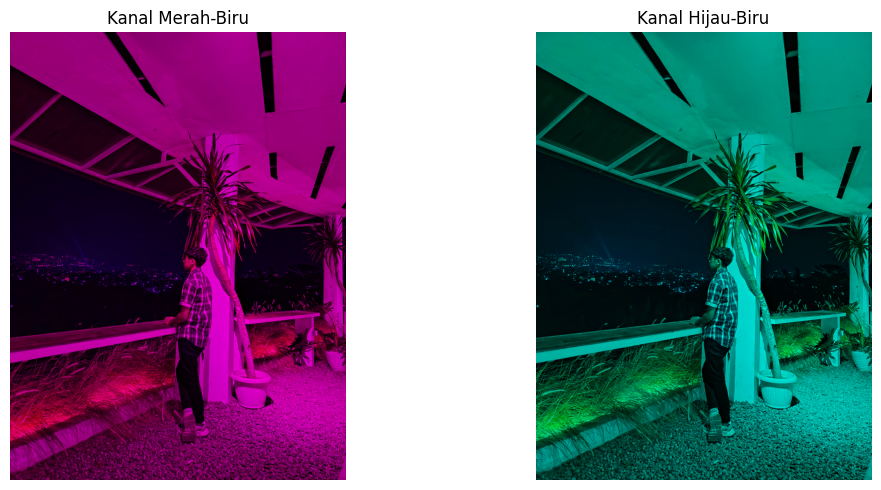

In [31]:
red_blue = img_rgb.copy()
red_blue[:, :, 1] = 0
green_blue = img_rgb.copy()
green_blue[:, :, 0] = 0

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(red_blue); ax[0].set_title('Kanal Merah-Biru')
ax[1].imshow(green_blue); ax[1].set_title('Kanal Hijau-Biru')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## Tugas Penerapan 2 - Tiga Bentuk Pencerminan

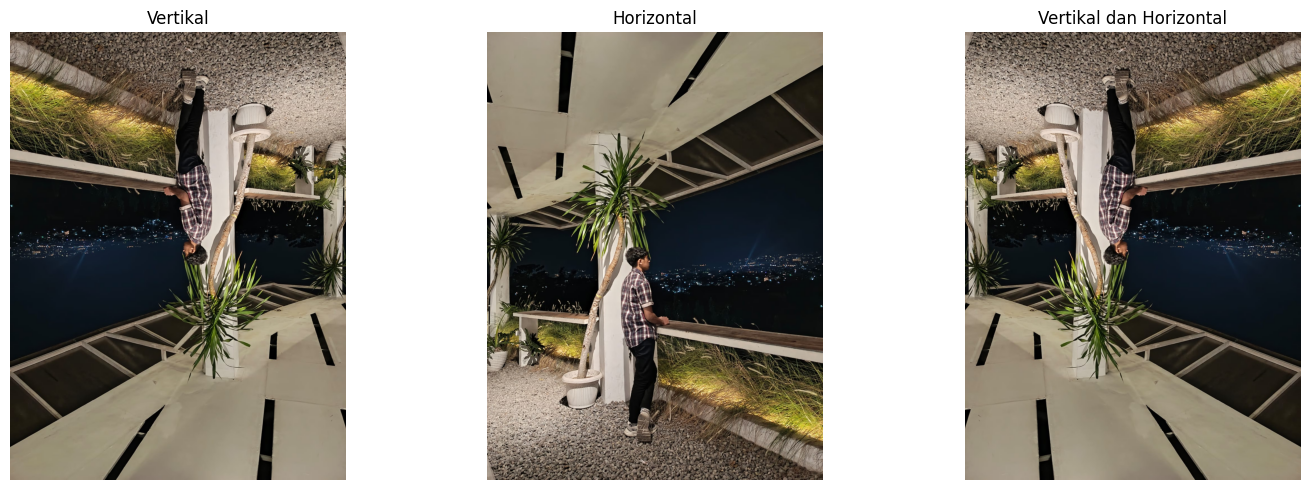

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, image, title in zip(ax, [vertical, horizontal, both], ['Vertikal', 'Horizontal', 'Vertikal dan Horizontal']):
    a.imshow(image); a.set_title(title); a.axis('off')
plt.tight_layout(); plt.show()

## Tugas Penerapan 3 - Rectangle, Circle, dan Nama

In [ ]:
annotated = img.copy()
h, w = annotated.shape[:2]
cv2.rectangle(annotated, (w // 4, h // 5), (3 * w // 4, 4 * h // 5), (0, 255, 0), max(1, w // 300))
cv2.circle(annotated, (w // 2, h // 2), min(h, w) // 6, (255, 0, 0), max(1, w // 300))
cv2.putText(annotated, 'Aldy', (w // 20, 19 * h // 20), cv2.FONT_HERSHEY_SIMPLEX, max(0.5, w / 800), (0, 0, 255), max(1, w // 300))
cv2_imshow(annotated)

## Tugas Analisa

**Pertanyaan:** Berapa persen piksel citra grayscale yang memiliki intensitas kurang dari 100?

Rancangan: konversi citra ke grayscale, hitung piksel dengan intensitas < 100, lalu bagi jumlahnya dengan total piksel. Hasil dan kesimpulan dicetak pada cell berikut.

In [ ]:
dark_pixels = np.sum(gray < 100)
total_pixels = gray.size
percentage = dark_pixels / total_pixels * 100
print('Piksel dengan intensitas < 100:', dark_pixels)
print('Total piksel:', total_pixels)
print(f'Persentase: {percentage:.2f}%')
print('Kesimpulan: persentase tersebut menunjukkan bagian citra yang tergolong lebih gelap dari ambang 100.')

## Tugas Aplikasi 1 - Label Adaptif

In [ ]:
def add_adaptive_label(image, text='Aldy'):
    output = image.copy()
    h, w = output.shape[:2]
    bar_h = max(20, h // 10)
    font_scale = max(0.4, w / 900)
    thickness = max(1, w // 500)
    cv2.rectangle(output, (0, h - bar_h), (w, h), (0, 0, 0), -1)
    cv2.putText(output, text, (w // 40, h - bar_h // 3), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness)
    return output

labeled = add_adaptive_label(img)
cv2_imshow(labeled)

## Tugas Aplikasi 2 - Thumbnail Persegi

In [ ]:
def square_thumbnail(image, text='Aldy Store'):
    h, w = image.shape[:2]
    side = max(h, w)
    canvas = np.full((side, side, 3), (230, 230, 230), dtype=image.dtype)
    y = (side - h) // 2
    x = (side - w) // 2
    canvas[y:y + h, x:x + w] = image
    font_scale = max(0.4, side / 900)
    thickness = max(1, side // 500)
    cv2.putText(canvas, text, (side // 30, side // 12), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 0, 0), thickness)
    return canvas

thumbnail = square_thumbnail(img)
cv2_imshow(thumbnail)